In [23]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

import json
with open("config.json") as f:
    config = json.load(f)
network_order = config['networks']

# Average spectrum

In [ ]:
dfs = []
stats_dfs = []
stats_dfs_nomotion = []
for strategy in config['strategies']:
    try:
        df_strategy = pd.read_csv('data/results/spectra_by_frequency_network_'+strategy+'.csv', low_memory=False)
        df_strategy['strategy'] = strategy
        dfs.append(df_strategy)
        stats_strategy = pd.read_csv('data/results/logpower_stats_by_frequency_network_'+strategy+'.csv')
        stats_strategy['strategy'] = strategy
        stats_dfs.append(stats_strategy)
        stats_strategy_nomotion = pd.read_csv('data/results/logpower_stats_by_frequency_network_nomotion_'+strategy+'.csv')
        stats_strategy_nomotion['strategy'] = strategy
        stats_dfs_nomotion.append(stats_strategy_nomotion)
    except FileNotFoundError:
        print(f"File for strategy {strategy} not found, skipping.")

spectrum_df = pd.concat(dfs, ignore_index=True)
stats_df = pd.concat(stats_dfs, ignore_index=True)
stats_df = stats_df[stats_df['covariate']=='PPL_mcg_L']
stats_df_nomotion = pd.concat(stats_dfs_nomotion, ignore_index=True)
stats_df_nomotion = stats_df_nomotion[stats_df_nomotion['covariate']=='PPL_mcg_L']

category_cols = ['subject', 'time_interval', 'strategy', 'network', 'frequency', 'scanner', 'num_vols']
numeric_cols = ['partial_residuals','partial_residuals_nomotion', 'log_power']
spectrum_df_avg_within_subject = spectrum_df.groupby(category_cols, as_index=False)[numeric_cols].mean()

/tmp/ipykernel_70385/4258894729.py:6: DtypeWarning: Columns (32) have mixed types. Specify dtype option on import or set low_memory=False.
  df_strategy = pd.read_csv('data/results/spectra_by_frequency_network_'+strategy+'.csv')
/tmp/ipykernel_70385/4258894729.py:6: DtypeWarning: Columns (32) have mixed types. Specify dtype option on import or set low_memory=False.
  df_strategy = pd.read_csv('data/results/spectra_by_frequency_network_'+strategy+'.csv')
/tmp/ipykernel_70385/4258894729.py:6: DtypeWarning: Columns (32) have mixed types. Specify dtype option on import or set low_memory=False.
  df_strategy = pd.read_csv('data/results/spectra_by_frequency_network_'+strategy+'.csv')
/tmp/ipykernel_70385/4258894729.py:6: DtypeWarning: Columns (32) have mixed types. Specify dtype option on import or set low_memory=False.
  df_strategy = pd.read_csv('data/results/spectra_by_frequency_network_'+strategy+'.csv')
/tmp/ipykernel_70385/4258894729.py:6: DtypeWarning: Columns (32) have mixed types. S

strategy, time interval, partial residuals

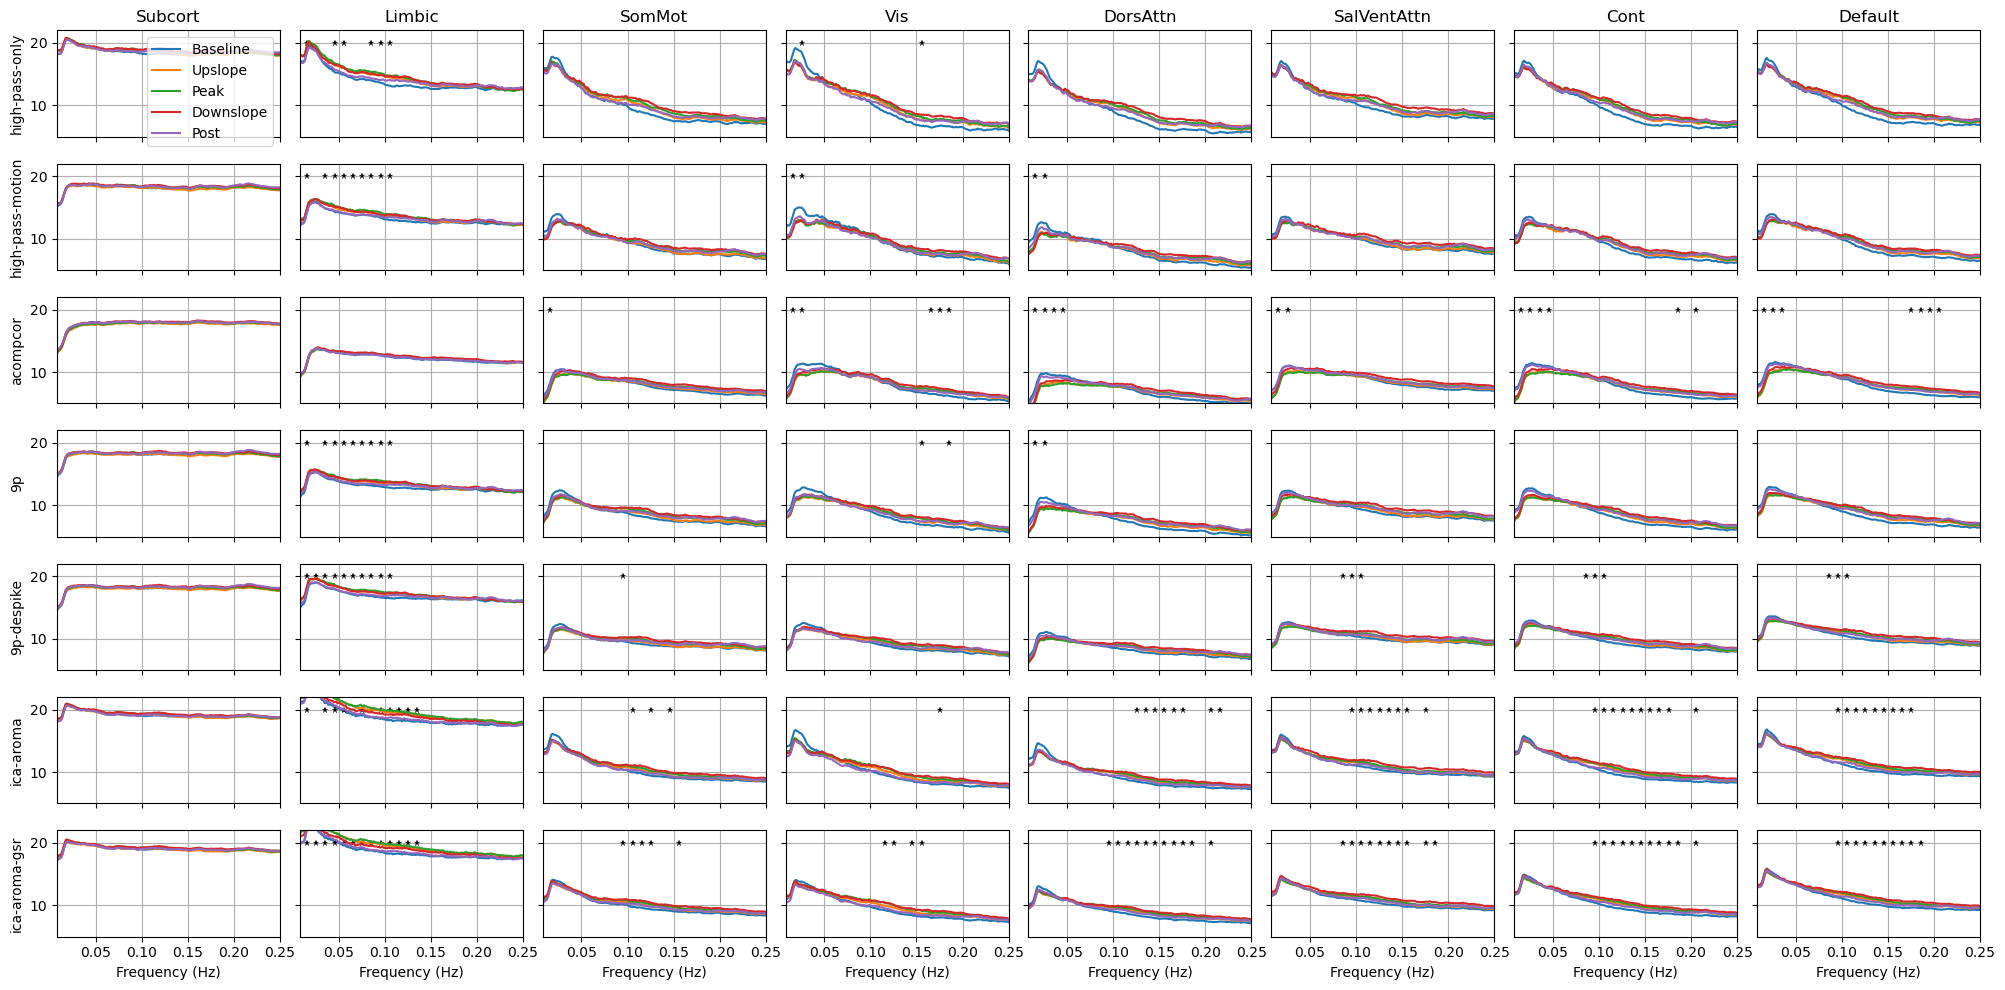

In [25]:
asterisk_loc = 20
fig,axs = plt.subplots(len(config['strategies']),8, figsize=(20, 10), sharex=True, sharey=True, layout='tight')
spectrum_df_avg = spectrum_df_avg_within_subject.groupby(['strategy', 'time_interval', 'network', 'frequency'], as_index=False)[numeric_cols].mean()
frequencies = np.loadtxt('data/frequencies_MR45.txt')  
for s,strategy in enumerate(config["strategies"]):
    for n,network in enumerate(network_order):
        ax = axs[s,n]
        stat_reduced_df = stats_df_nomotion[(stats_df_nomotion['uncontrolled'] == network) & (stats_df_nomotion['strategy'] == strategy)]
        for t,time_interval in enumerate(config["time_intervals"]):
            network_spectrum = spectrum_df_avg[(spectrum_df_avg['network'] == network) & (spectrum_df_avg['strategy'] == strategy) & (spectrum_df_avg['time_interval'] == time_interval)]
            
            ax.plot(network_spectrum['frequency'], network_spectrum['partial_residuals_nomotion'], label=time_interval)

            # plot asterisks for significant changes
            if t==0:
                for i,row in stat_reduced_df.iterrows():
                    if row['pval'] < 0.05/8:
                        ax.plot(row['controlled'],asterisk_loc, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)

            if s == 6:
                ax.set_xlabel('Frequency (Hz)')
            ax.grid()
            # ax.legend(networks, loc='upper right')
            # ax.set_xlim([0, 0.25])  # Adjust x-axis limits as needed      
            if s == 0:
                ax.set_title(network)
            if s==0 and n==0:
                ax.legend(loc='upper right')
            if n == 0:
                ax.set_ylabel(strategy)  
            
            ax.set_ylim([5, 22])
            ax.set_xlim([0.008, 0.25])
fig.savefig('figures/aggregated_power_maps/bands_partial_residuals_nomotion.png', bbox_inches='tight', dpi=300)

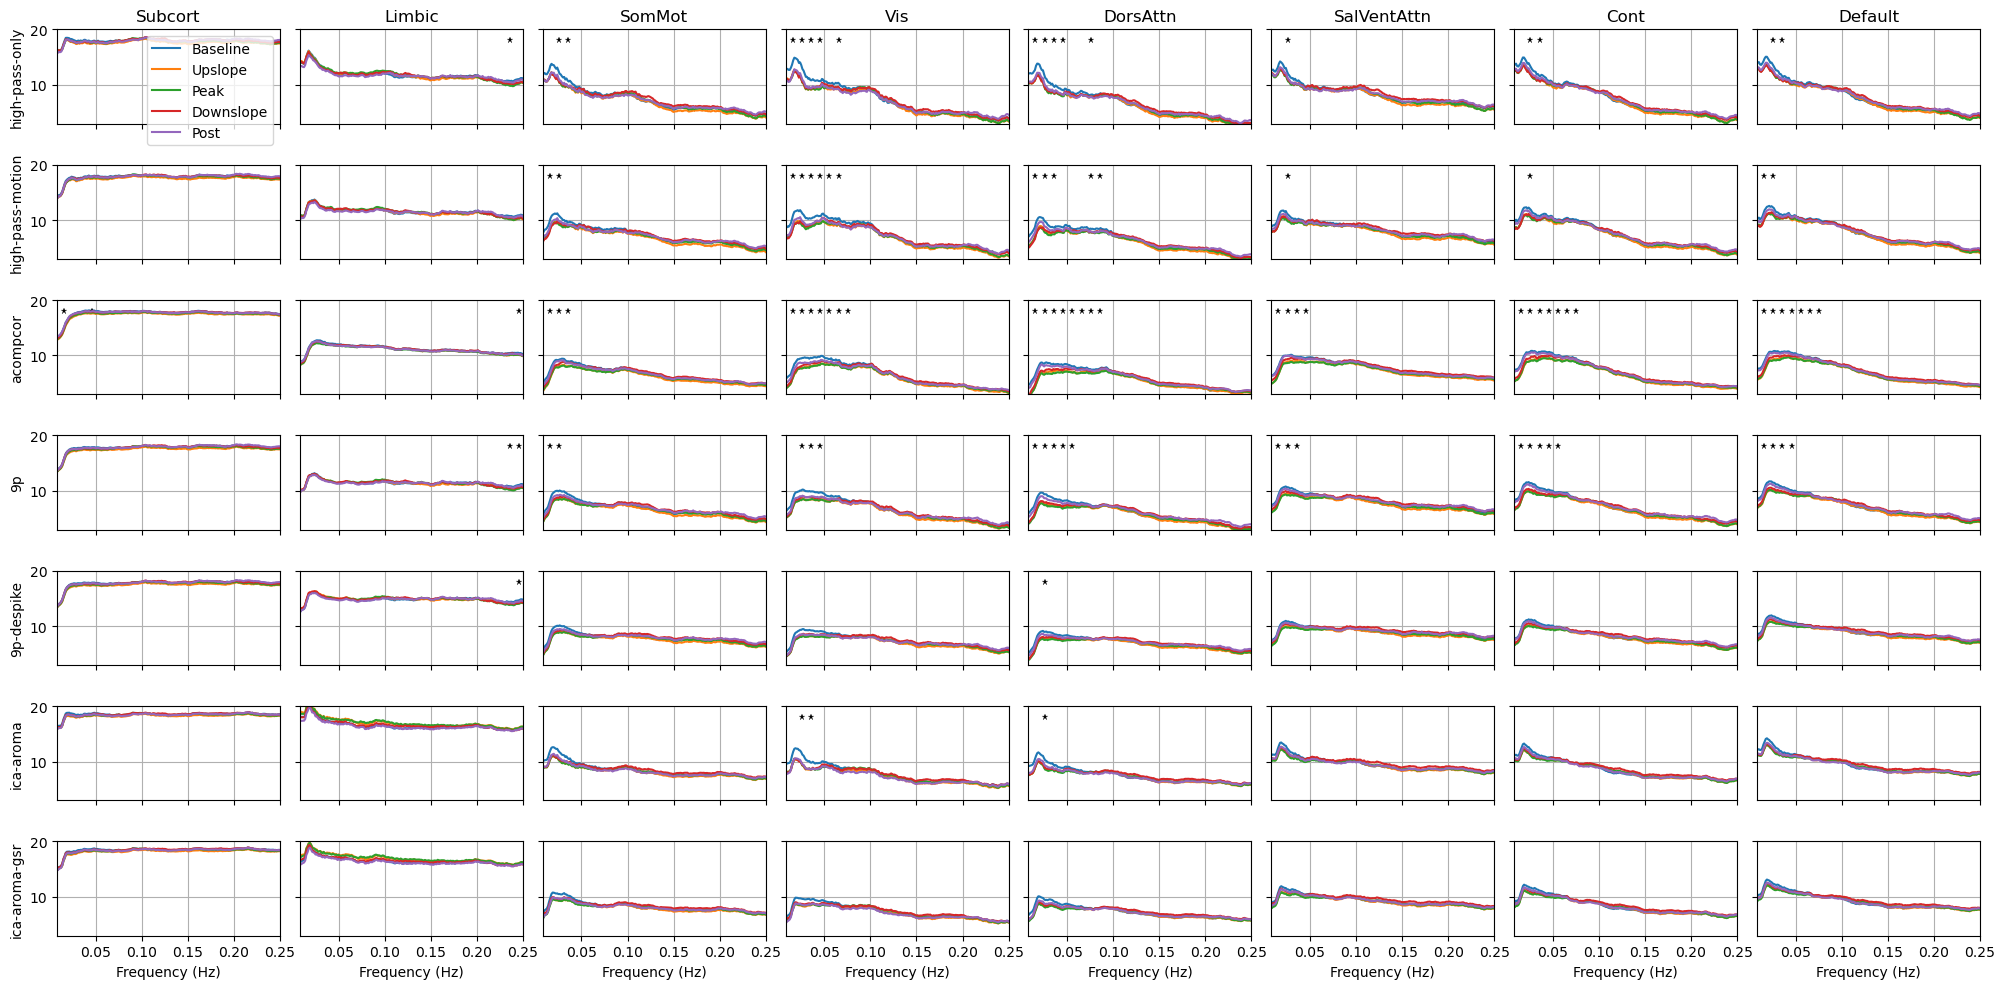

In [26]:
asterisk_loc = 18
fig,axs = plt.subplots(len(config['strategies']),8, figsize=(20, 10), sharex=True, sharey=True, layout='tight')
spectrum_df_avg = spectrum_df_avg_within_subject.groupby(['strategy', 'time_interval', 'network', 'frequency'], as_index=False)[numeric_cols].mean()
frequencies = np.loadtxt('data/frequencies_MR45.txt')  
for s,strategy in enumerate(config["strategies"]):
    for n,network in enumerate(network_order):
        ax = axs[s,n]
        stat_reduced_df = stats_df[(stats_df['uncontrolled'] == network) & (stats_df['strategy'] == strategy)]
        for t,time_interval in enumerate(config["time_intervals"]):
            network_spectrum = spectrum_df_avg[(spectrum_df_avg['network'] == network) & (spectrum_df_avg['strategy'] == strategy) & (spectrum_df_avg['time_interval'] == time_interval)]
            
            ax.plot(network_spectrum['frequency'], network_spectrum['partial_residuals'], label=time_interval)

            # plot asterisks for significant changes
            if t==0:
                for i,row in stat_reduced_df.iterrows():
                    if row['pval'] < 0.05/8:
                        ax.plot(row['controlled'],asterisk_loc, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)

            if s == 6:
                ax.set_xlabel('Frequency (Hz)')
            ax.grid()
            # ax.legend(networks, loc='upper right')
            # ax.set_xlim([0, 0.25])  # Adjust x-axis limits as needed      
            if s == 0:
                ax.set_title(network)
            if s==0 and n==0:
                ax.legend(loc='upper right')
            if n == 0:
                ax.set_ylabel(strategy)  
            
            ax.set_ylim([3, 20])
            ax.set_xlim([0.008, 0.25])
            # ax.set_xscale('log')
fig.savefig('figures/aggregated_power_maps/bands_partial_residuals.png', bbox_inches='tight', dpi=300)

Divided into two scanners to look at respiration

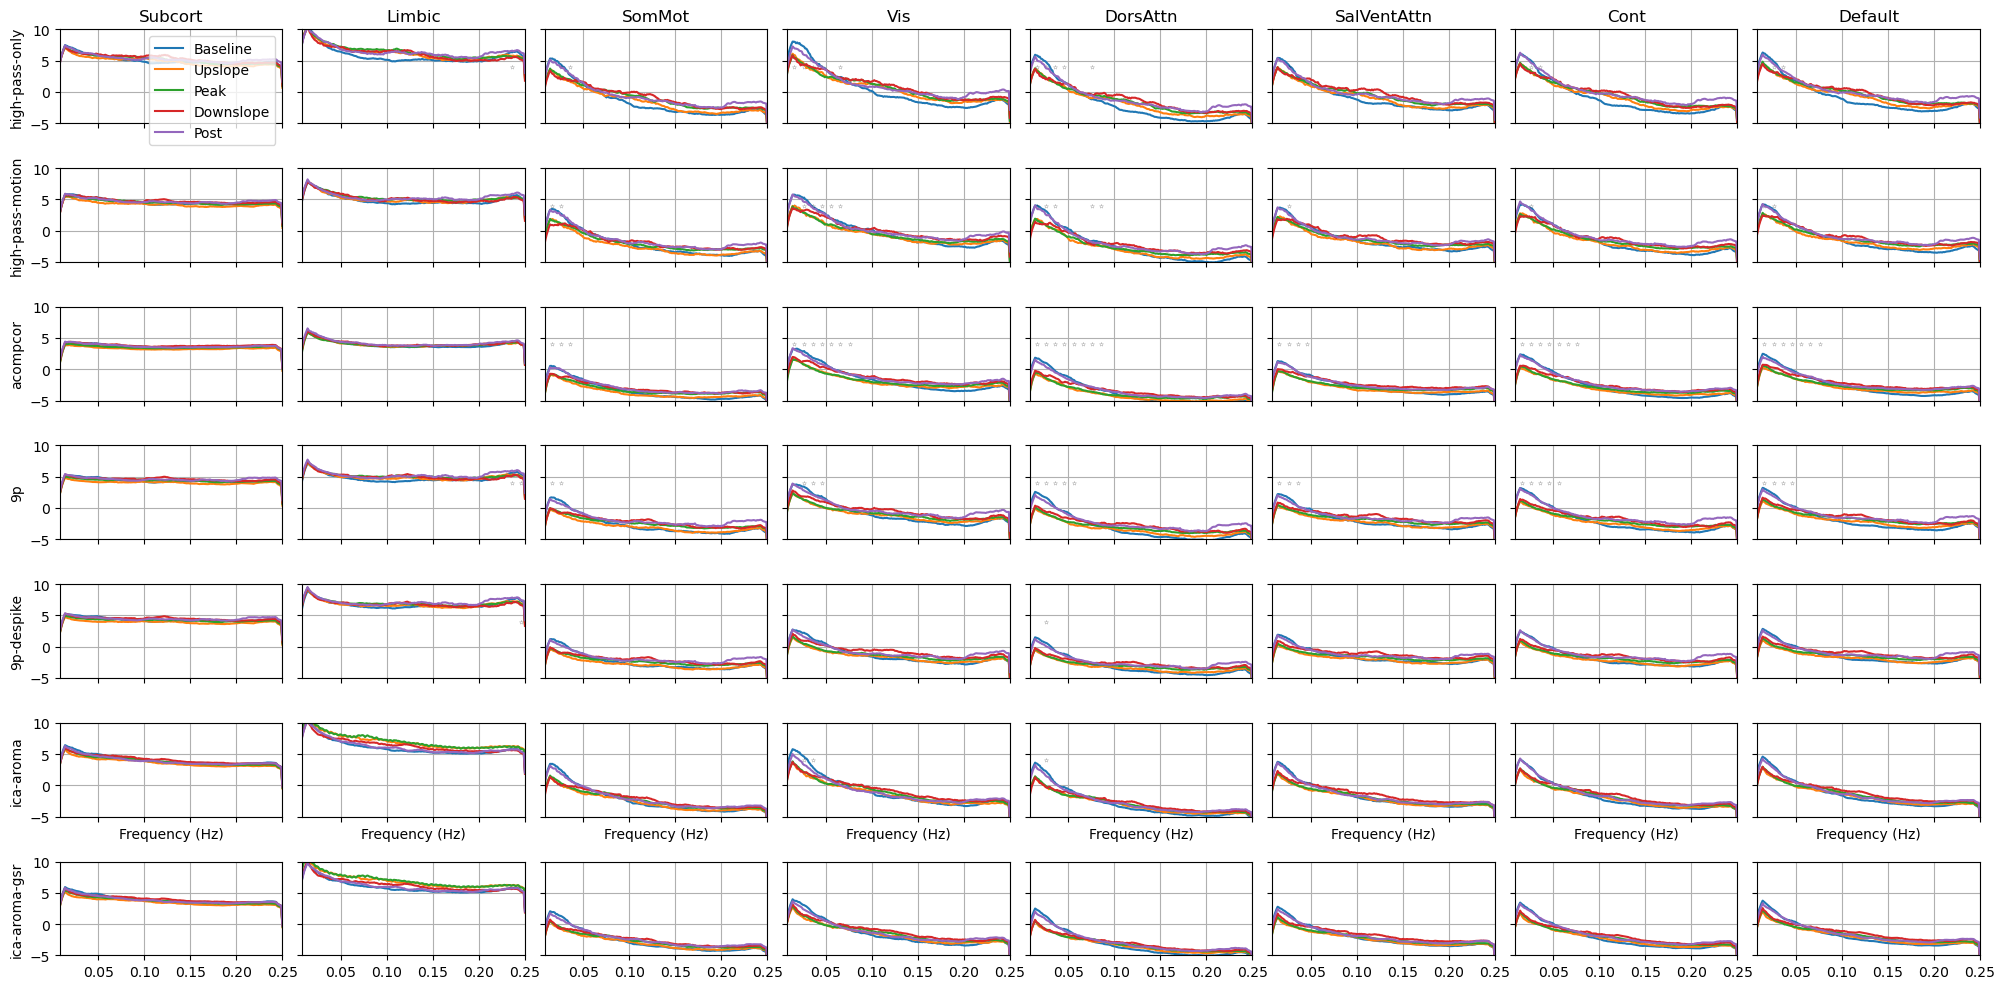

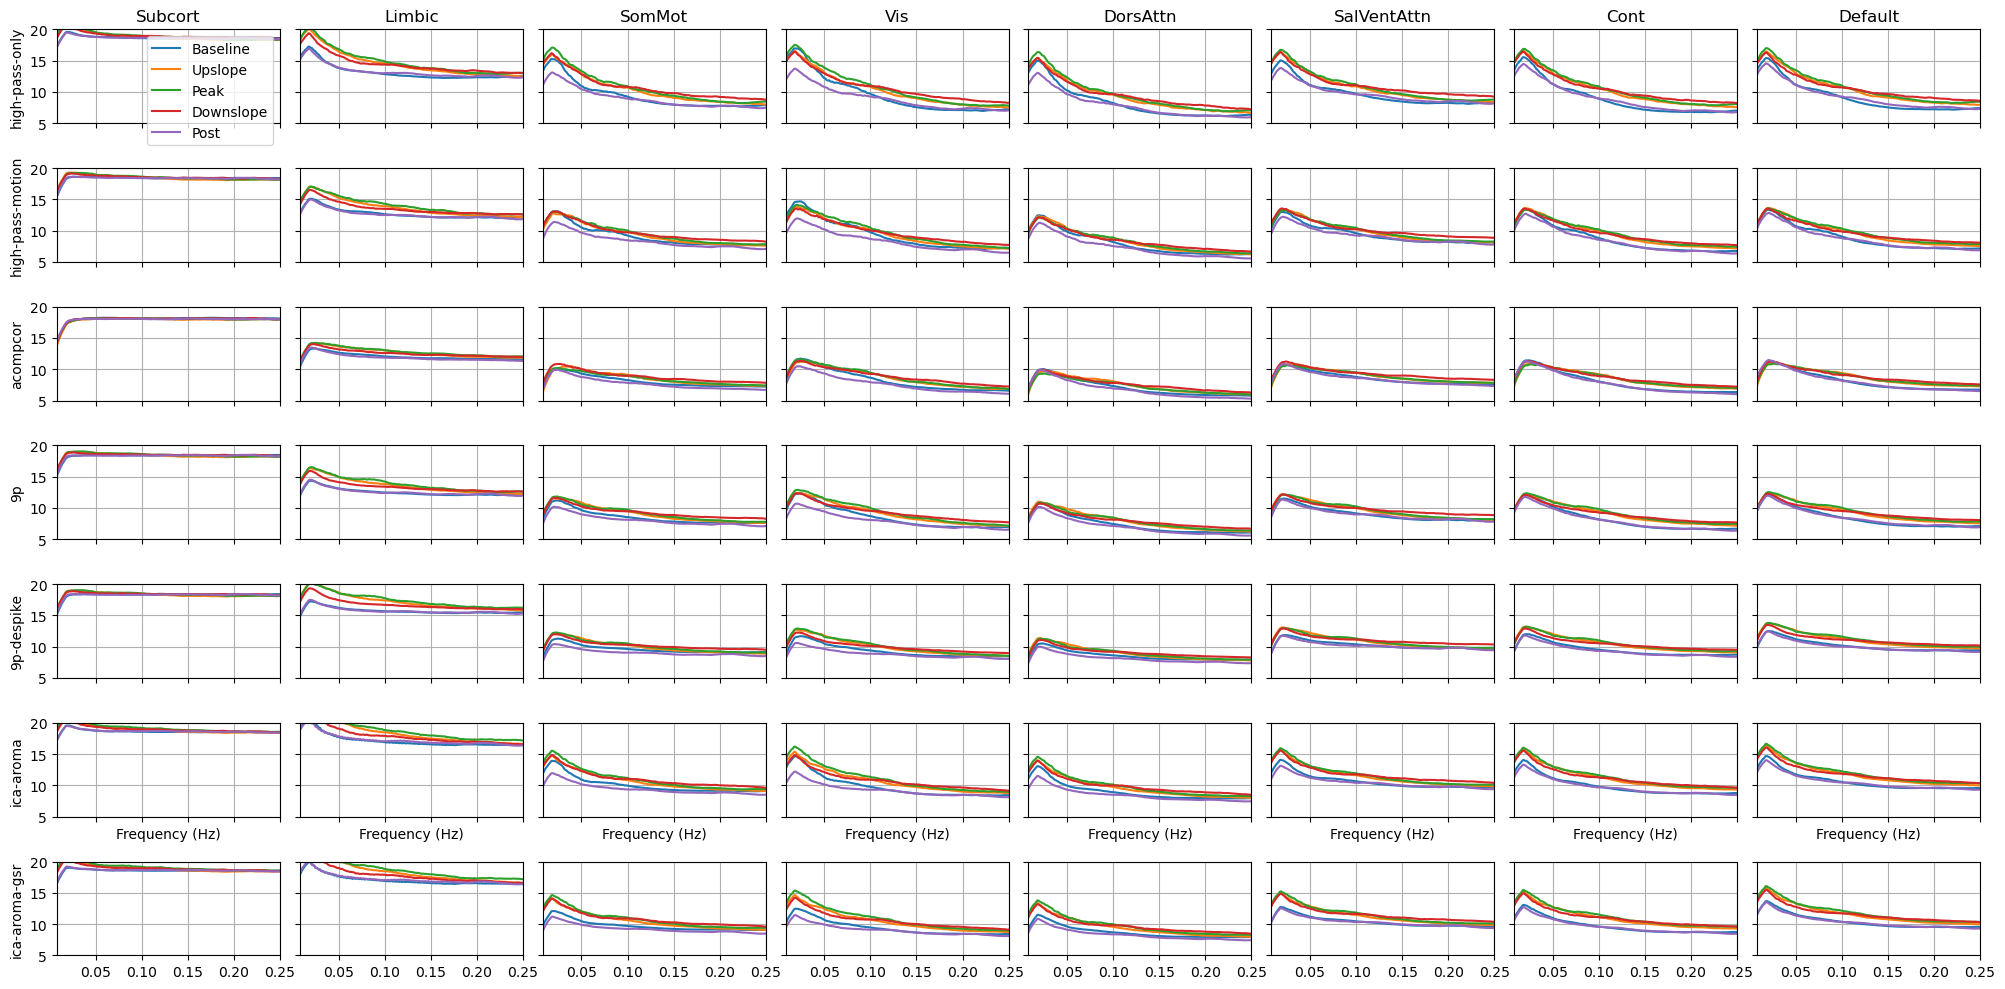

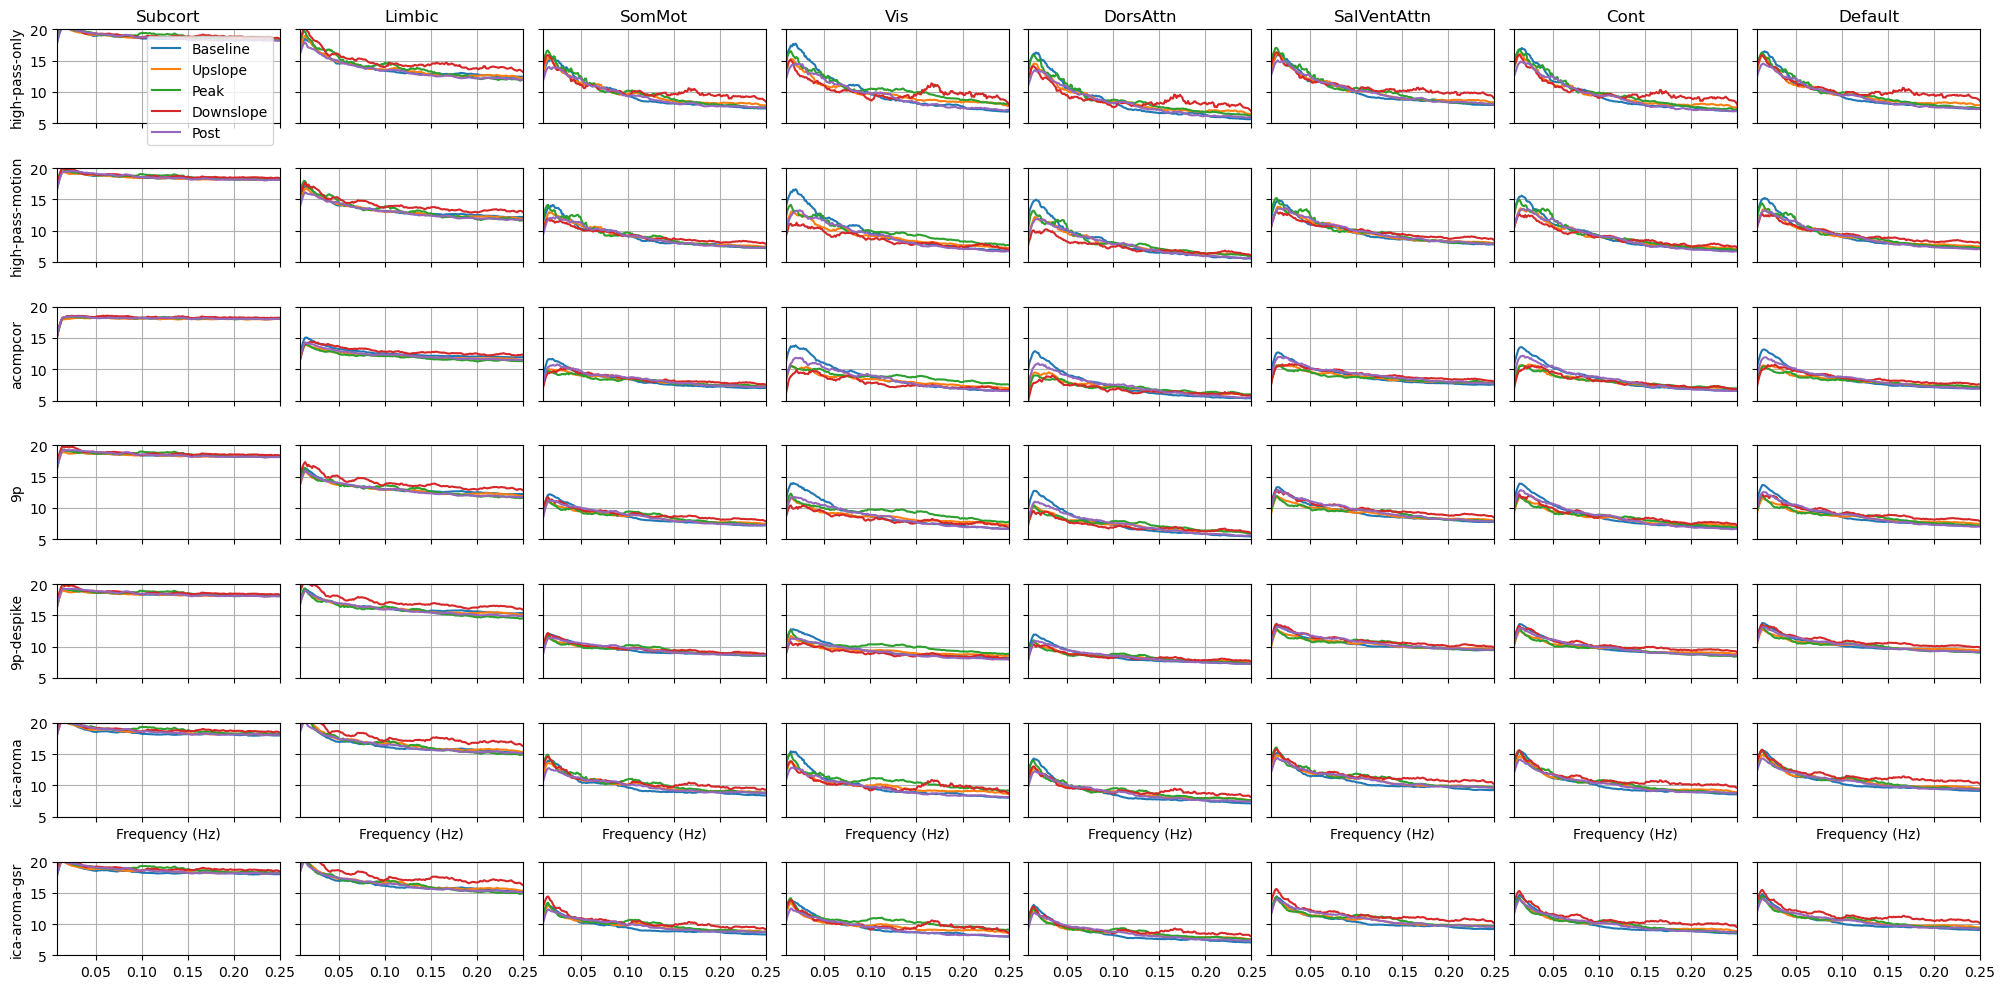

In [ ]:
asterisk_loc = 4
for num_vols in spectrum_df_avg_within_subject['num_vols'].unique():
    fig,axs = plt.subplots(len(config['strategies']),8, figsize=(20, 10), sharex=True, sharey=True, layout='tight')
    spectrum_df_avg = spectrum_df_avg_within_subject.groupby(['strategy', 'time_interval', 'network', 'frequency', 'num_vols', 'scanner'], as_index=False)[numeric_cols].mean()
    spectrum_df_avg = spectrum_df_avg[spectrum_df_avg['num_vols'] == num_vols]
    frequencies = np.loadtxt('data/frequencies_'+spectrum_df_avg.iloc[0].scanner+'.txt')  
    for s,strategy in enumerate(config["strategies"]):
        for n,network in enumerate(network_order):
            ax = axs[s,n]
            stat_reduced_df = stats_df[(stats_df['uncontrolled'] == network) & (stats_df['strategy'] == strategy)]
            for t,time_interval in enumerate(config["time_intervals"]):
                network_spectrum = spectrum_df_avg[(spectrum_df_avg['network'] == network) & (spectrum_df_avg['strategy'] == strategy) & (spectrum_df_avg['time_interval'] == time_interval)]
                
                ax.plot(network_spectrum['frequency'], network_spectrum['log_power'], label=time_interval)

                # plot asterisks for significant changes
                if t==0:
                    for i,row in stat_reduced_df.iterrows():
                        if row['pval'] < 0.05/8:
                            ax.plot(row['controlled'],asterisk_loc, marker='*', markersize=3, color='black', markeredgecolor='black', markeredgewidth=0.1, fillstyle='none')

                if s == 6:
                    ax.set_xlabel('Frequency (Hz)')
                ax.grid()
                # ax.legend(networks, loc='upper right')
                # ax.set_xlim([0, 0.25])  # Adjust x-axis limits as needed      
                if s == 0:
                    ax.set_title(network)
                if s==0 and n==0:
                    ax.legend(loc='upper right')
                if n == 0:
                    ax.set_ylabel(strategy)  
                
                if spectrum_df_avg.iloc[0].scanner=='MR45':
                    ax.set_xlim([0.008, 0.25])
                    ax.set_ylim([-5, 10])
                elif num_vols==375:
                    ax.set_xlim([0.008, 0.25])
                    ax.set_ylim([5,20])
                else:
                    ax.set_xlim([0.008, 0.25])
                    ax.set_ylim([5,20])
                # ax.set_xscale('log')
                # ax.set_ylim([0,25])
    fig.savefig('figures/aggregated_power_maps/bands_partial_residuals_'+str(num_vols)+'.png', bbox_inches='tight', dpi=300)

Only ica-aroma-gsr, bonfferoni corrected

In [ ]:
# asterisk_loc = 4
# fig,axs = plt.subplots(2,4, figsize=(8, 4), sharex=True, sharey=True, layout='tight')
# spectrum_df_avg = spectrum_df_avg_within_subject
# # spectrum_df_avg = spectrum_df_avg.drop(columns=['subject', 'session', 'task', 'run','MR','age','sex'])
# spectrum_df_avg = spectrum_df_avg.drop(columns=[c for c in spectrum_df_avg.columns if c not in ['strategy', 'time_interval', 'network', 'frequency', 'partial_residuals_age-sex-scanner']])
# spectrum_df_avg = spectrum_df_avg.groupby(['strategy', 'time_interval', 'network', 'frequency']).mean().reset_index()
# # mean_spectrum_025 = np.mean(np.array(mean_spectrum_all_025), axis=0)
# frequencies = np.loadtxt('data/frequencies_MR45.txt')  
# for n,network in enumerate(network_order):
#     for t,time_interval in enumerate(config["time_intervals"]):
#         # Get the axis for the current subplot           
#         # ax = axs[s,n]
#         ax = axs.flatten()[n]
#         network_spectrum = spectrum_df_avg[(spectrum_df_avg['network'] == network) & (spectrum_df_avg['strategy'] == strategy) & (spectrum_df_avg['time_interval'] == time_interval)]
#         stat_reduced_df = stats_df[(stats_df['network'] == network) & (stats_df['strategy'] == strategy)]
#         ax.plot(network_spectrum['frequency'], network_spectrum['partial_residuals_age-sex-scanner'], label=time_interval)

#         # plot asterisks for significant changes
#         for i,row in stat_reduced_df.iterrows():
#             if row['pval'] < 0.05 / stat_reduced_df.shape[0]:
#                 ax.plot(row['frequency'],asterisk_loc, marker='*', markersize=3, color='black', markeredgecolor='black', markeredgewidth=0.1, fillstyle='none')

#         if s == 4:
#             ax.set_xlabel('Frequency (Hz)')
#         ax.grid()
#         # ax.legend(networks, loc='upper right')
#         # ax.set_xlim([0, 0.25])  # Adjust x-axis limits as needed      
#         # if s == 0:
#         ax.set_title(network)
#         if s==0 and n==0:
#             ax.legend(loc='upper right')
#         # if n == 0:
#             # ax.set_ylabel(strategy)  
        
#         ax.set_ylim([3.7, 5.1])
#         ax.set_xlim([0.008, 0.25])
#         ax.set_xscale('log')
# fig.savefig('figures/aggregated_power_maps/bands_partial_residuals_icaaromagsr.png', bbox_inches='tight', dpi=300)

# All spectra save figure in folder for look-through

In [ ]:
# find denoising directories
df = pd.read_csv('data/func_scans_table_outliers_ses-PSI_PPLSDI.csv')
df = df[df['task']==config["task"]]
df = df[df['ratio_outliers_fd0.5_std_dvars1000']<config['ratio_outliers_fd0_5_std_dvars1000']]
df = df[df['include_manual_qc']]
df = df[df['include_scan_coil_numvols']]
df = df[df['max_fd']<config['scan_max_fd_threshold']]
spectrum_top_dir = 'data/spectra'
ts_top_dir = 'data/denoised'
subjects = df['subject'].unique()
networks = config["networks"]
from spectral_analysis.helper_functions import import_mask_and_parcellation
parcel_labels,_,_,_ = import_mask_and_parcellation()
for strategy in config["strategies"]:
    print(f"Processing strategy: {strategy}")
    for index, scan in df.iterrows():
        # print(f"Processing scan: {scan.subject} {scan.session} {scan.task} {scan.run}")

        ts_dir = ts_top_dir + '/' + strategy + '/' + scan.subject + '/' + scan.session + '/func/'
        spectrum_dir = spectrum_top_dir + '/' + strategy + '/' + scan.subject + '/' + scan.session + '/func/'
        try:
            ts_file = os.path.join(ts_dir, os.path.basename(scan['preproc_filename_cifti']).replace('.dtseries.nii', '_denoised_parcellated_schaefertian232.txt'))
            spectrum_file = os.path.join(spectrum_dir, os.path.basename(scan['preproc_filename_cifti']).replace('.dtseries.nii', '_mtspectra_parcellated_schaefertian232.txt'))
        
            parcellated_ts = np.loadtxt(ts_file)
            parcellated_spectrum = np.loadtxt(spectrum_file)
        except:
            print(f"Scan {scan['preproc_filename_cifti']} does not exist, skipping")
            continue

        if scan.scanner == 'MR45':
            frequencies = np.loadtxt('data/frequencies_MR45.txt')
        elif scan.scanner == 'MR001':
            frequencies = np.loadtxt('data/frequencies_MR001.txt')
        
        mean_ts = np.zeros((parcellated_ts.shape[0], len(networks)))
        mean_spectra = np.zeros((parcellated_spectrum.shape[0], len(networks)))
        for i,network in enumerate(networks):
            mask = np.array([network in label for label in parcel_labels])

            mean_ts[:, i] = np.nanmean(parcellated_ts[:, mask], axis=1)
            mean_spectra[:, i] = np.nanmean(parcellated_spectrum[:, mask], axis=1)
            
        # Plot the mean spectrum
        fig,axs = plt.subplots(2,1, figsize=(10, 10))
        axs[0].plot( mean_ts)
        axs[0].set_title(f"{scan.subject} - {scan.session} - {scan.task} - {scan.run}")
        axs[0].set_xlabel('Time (s)')
        axs[0].set_ylabel('Signal (percent change)')
        axs[0].grid()   
        axs[0].legend(networks, loc='upper right')
        axs[1].plot(frequencies,mean_spectra)
        axs[1].set_title(f"{scan.subject} - {scan.session} - {scan.task} - {scan.run}")
        axs[1].set_xlabel('Frequency (Hz)')
        axs[1].set_ylabel('Power')
        axs[1].grid()
        axs[1].legend(networks, loc='upper right')
        axs[1].set_xlim([0, 0.25])  # Adjust x-axis limits as needed

        # Save the plot
        plot_filename = "figures/mtspectra/"+strategy+"/"+scan.subject+"_"+scan.session+"_"+scan.task+"_"+scan.run+"_"+strategy+".png"
        os.makedirs(os.path.dirname(plot_filename), exist_ok=True)
        fig.savefig(plot_filename)
        plt.close()

Processing strategy: high-pass-only
Scan nan does not exist, skipping
Processing strategy: high-pass-motion
Scan nan does not exist, skipping
Processing strategy: acompcor
Scan nan does not exist, skipping
Processing strategy: 9p
Scan nan does not exist, skipping
Processing strategy: 9p-despike
Scan nan does not exist, skipping
Processing strategy: ica-aroma
Scan nan does not exist, skipping
Processing strategy: ica-aroma-gsr
Scan nan does not exist, skipping
